# Combined Score: Composite Risk × Safety
Combines the Lens 1 (`SpeedSafetyScore`) and Lens 2 (`RiskScore`) into a single `CompositeScore`, merges in the rule-based policy recommendations from `policy_rec/`, and builds one interactive map with toggles for country (India / Thailand) and score type (Safety / Risk / Composite / Policy Recommendation).

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt
import folium
import json
import matplotlib.pyplot as plt

## Load Data

Both lenses were computed independently and saved to `data/*_safety_score.csv` and `data/*_risk_score.csv`, with geometry stored as WKT. Lens 2 dropped rows without street-level image coverage, so the risk tables are a subset of the safety tables — the merge below keeps only segments present in both.

In [2]:
def load_score_csv(path):
    df = pd.read_csv(path)
    df['geometry'] = df['geometry'].apply(wkt.loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

india_safety = load_score_csv('data/india_safety_score.csv')
india_risk   = load_score_csv('data/india_risk_score.csv')
thai_safety  = load_score_csv('data/thai_safety_score.csv')
thai_risk    = load_score_csv('data/thai_risk_score.csv')

print(f"India    — safety: {india_safety.shape}, risk: {india_risk.shape}")
print(f"Thailand — safety: {thai_safety.shape}, risk: {thai_risk.shape}")

India    — safety: (3577, 39), risk: (3421, 51)
Thailand — safety: (11134, 41), risk: (11062, 58)


## Merge Safety + Risk per Country

In [3]:
def merge_safety_risk(safety_gdf, risk_gdf):
    risk_cols = ['OBJECTID', 'RiskScore', 'PriorityTier']

    merged = safety_gdf.merge(
        risk_gdf[risk_cols].rename(columns={'PriorityTier': 'RiskPriorityTier'}),
        on='OBJECTID', how='inner'
    )
    merged = merged.rename(columns={'PriorityTier': 'SafetyPriorityTier'})
    return merged

india_combined = merge_safety_risk(india_safety, india_risk)
thai_combined  = merge_safety_risk(thai_safety, thai_risk)

print(f"India combined: {india_combined.shape} | Thailand combined: {thai_combined.shape}")

India combined: (3421, 41) | Thailand combined: (11062, 43)


## Composite Score

`CompositeScore` is a simple 50/50 average of `SpeedSafetyScore` and `RiskScore` — both lenses are already independently rescaled to 0–100 within each country, so no further normalisation is needed before combining them. Equal weighting reflects that speed-related risk and infrastructure/exposure risk are treated as equally important contributors to overall danger. Segments are bucketed into the same four priority tiers used by the individual lenses.

In [4]:
def compute_composite_score(gdf):
    gdf = gdf.copy()
    gdf['CompositeScore'] = 0.5 * gdf['SpeedSafetyScore'] + 0.5 * gdf['RiskScore']
    gdf['CompositePriorityTier'] = pd.cut(
        gdf['CompositeScore'],
        bins=[0, 25, 50, 75, 100],
        labels=['Low', 'Medium', 'High', 'Critical'],
        include_lowest=True
    )
    return gdf

india_combined = compute_composite_score(india_combined)
thai_combined  = compute_composite_score(thai_combined)

print("India composite distribution:")
print(india_combined['CompositeScore'].describe().round(2))
print("\nThailand composite distribution:")
print(thai_combined['CompositeScore'].describe().round(2))

India composite distribution:
count    3421.00
mean       25.65
std        12.03
min         1.03
25%        17.71
50%        24.43
75%        33.73
max        82.87
Name: CompositeScore, dtype: float64

Thailand composite distribution:
count    11062.00
mean        35.49
std         11.26
min          0.32
25%         28.39
50%         36.45
75%         43.19
max         75.31
Name: CompositeScore, dtype: float64


## Policy Recommendations

`policy_rec/*_priority_improvement.csv` holds a rule-based intervention recommendation per road segment (e.g. *Provide footpath*, *Add speed camera/speed limit enforcement*), keyed by `OBJECTID`, covering the full safety-lens road network. It's a descriptive label rather than a score, so it isn't blended into `CompositeScore` — instead it's merged in as an extra field and exposed as a fourth, independently browsable map layer.

In [5]:
def load_policy_csv(path):
    return pd.read_csv(path, usecols=['OBJECTID', 'priority_improvement'])

india_policy = load_policy_csv('policy_rec/india_priority_improvement.csv')
thai_policy  = load_policy_csv('policy_rec/thai_priority_improvement.csv')

india_combined = india_combined.merge(india_policy, on='OBJECTID', how='left')
thai_combined  = thai_combined.merge(thai_policy, on='OBJECTID', how='left')

india_combined['priority_improvement'] = india_combined['priority_improvement'].fillna('Unknown')
thai_combined['priority_improvement']  = thai_combined['priority_improvement'].fillna('Unknown')

print("India policy recommendations:")
print(india_combined['priority_improvement'].value_counts())
print("\nThailand policy recommendations:")
print(thai_combined['priority_improvement'].value_counts())

India policy recommendations:
priority_improvement
No priority intervention needed                                                                     2962
Add speed camera/speed limit enforcement                                                             150
Provide footpath                                                                                     117
Provide a traffic calming and safety crossing for pedestrians and cyclists                           108
Add pedestrian crossing and adjust the traffic light to prioritize pedestrians & cyclists safety      30
Add traffic calming and speed camera/speed limit enforcement                                          26
Provide a bridge for pedestrians and cyclists                                                         18
Clear footpaths                                                                                        8
Provide separated bike lane                                                                            1
Impr

## Validation

In [6]:
for name, gdf in [('India', india_combined), ('Thailand', thai_combined)]:
    print(f"{name}:")
    print("  Safety tiers:   ", gdf['SafetyPriorityTier'].value_counts().sort_index().to_dict())
    print("  Risk tiers:     ", gdf['RiskPriorityTier'].value_counts().sort_index().to_dict())
    print("  Composite tiers:", gdf['CompositePriorityTier'].value_counts().sort_index().to_dict())
    print()

India:
  Safety tiers:    {'Critical': 35, 'High': 146, 'Low': 2759, 'Medium': 481}
  Risk tiers:      {'Critical': 156, 'High': 771, 'Low': 991, 'Medium': 1503}
  Composite tiers: {'Low': 1782, 'Medium': 1531, 'High': 106, 'Critical': 2}

Thailand:
  Safety tiers:    {'Critical': 370, 'High': 5661, 'Low': 1785, 'Medium': 3246}
  Risk tiers:      {'Critical': 16, 'High': 679, 'Low': 5194, 'Medium': 5173}
  Composite tiers: {'Low': 1812, 'Medium': 8319, 'High': 930, 'Critical': 1}



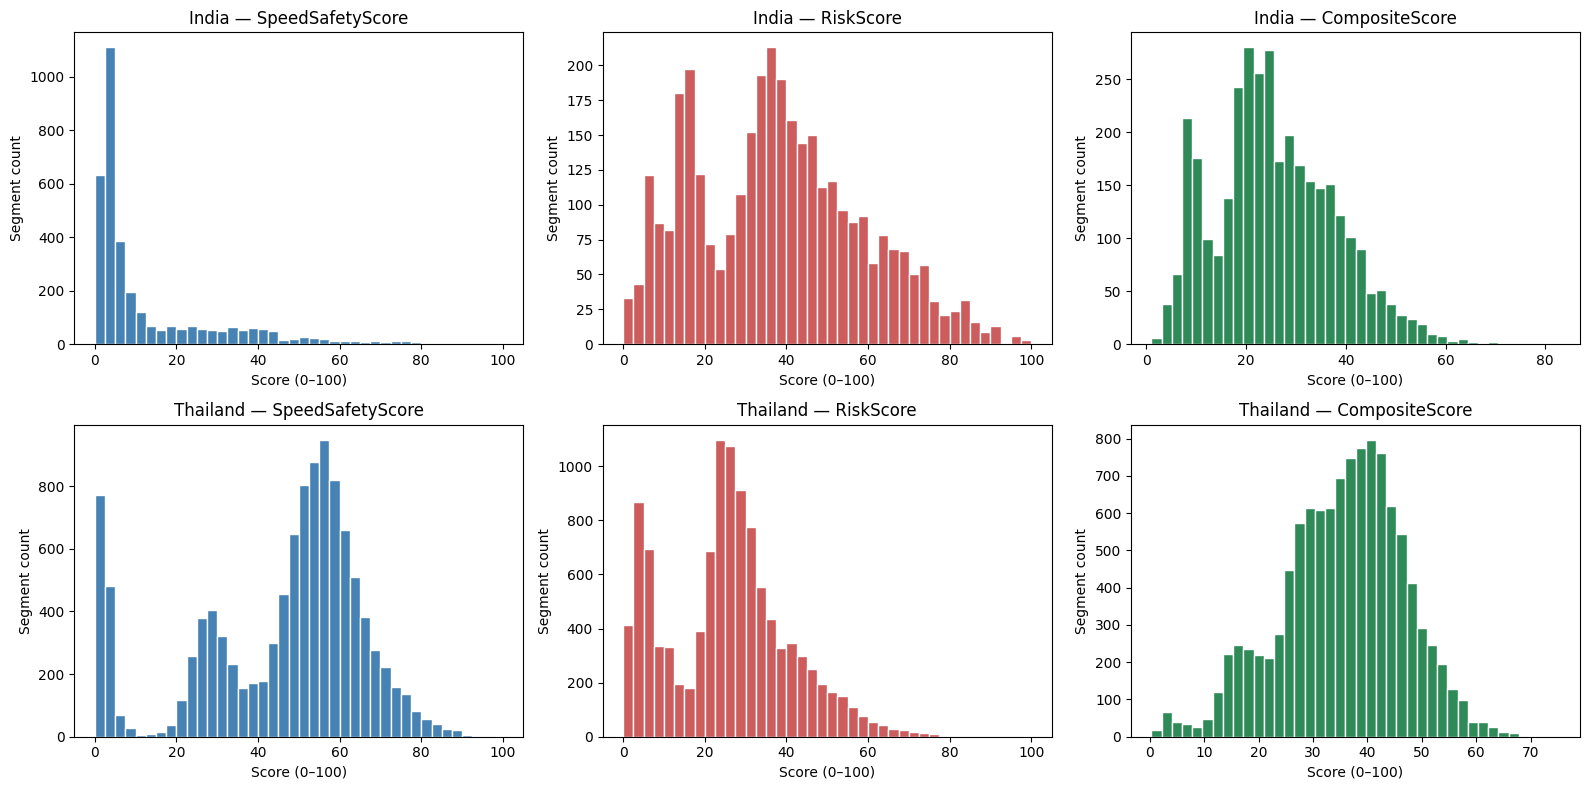

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for row, (name, gdf) in zip(axes, [('India', india_combined), ('Thailand', thai_combined)]):
    for ax, (col, colour) in zip(row, [('SpeedSafetyScore', 'steelblue'), ('RiskScore', 'indianred'), ('CompositeScore', 'seagreen')]):
        ax.hist(gdf[col], bins=40, color=colour, edgecolor='white')
        ax.set_title(f'{name} — {col}')
        ax.set_xlabel('Score (0–100)')
        ax.set_ylabel('Segment count')
plt.tight_layout()
plt.show()

In [8]:
for name, gdf in [('India', india_combined), ('Thailand', thai_combined)]:
    corr = gdf[['SpeedSafetyScore', 'RiskScore']].corr().iloc[0, 1]
    print(f"{name}: correlation(SpeedSafetyScore, RiskScore) = {corr:.3f}")

India: correlation(SpeedSafetyScore, RiskScore) = -0.193
Thailand: correlation(SpeedSafetyScore, RiskScore) = -0.245


### Save the combined scores

In [9]:
india_combined.to_csv('data/india_composite_score.csv', index=False)
thai_combined.to_csv('data/thai_composite_score.csv', index=False)

## Interactive Map — Toggle Country × Score Type

A single map with eight hidden layers (2 countries × 4 score types: Safety, Risk, Composite, Policy Recommendation). Two dropdown controls toggle which layer is shown; only the active layer's features are rendered to the DOM, so switching stays fast even though all data is embedded in the page. The legend swaps between the priority-tier key and the policy-recommendation key depending on which score type is active.

In [10]:
tier_colours = {
    'Low':      '#2ecc71',
    'Medium':   '#f39c12',
    'High':     '#e74c3c',
    'Critical': '#8e44ad',
}

policy_colours = {
    'No priority intervention needed':                                                                  '#2ecc71',
    'Add speed camera/speed limit enforcement':                                                          '#3498db',
    'Provide footpath':                                                                                  '#e67e22',
    'Provide a traffic calming and safety crossing for pedestrians and cyclists':                        '#e74c3c',
    'Add pedestrian crossing and adjust the traffic light to prioritize pedestrians & cyclists safety':  '#9b59b6',
    'Add traffic calming and speed camera/speed limit enforcement':                                      '#f1c40f',
    'Provide a bridge for pedestrians and cyclists':                                                     '#1abc9c',
    'Clear footpaths':                                                                                   '#34495e',
    'Provide separated bike lane':                                                                       '#16a085',
    'Improve lane marking':                                                                               '#7f8c8d',
    'Unknown':                                                                                            '#888888',
}

# Kept for labels only — value_col/colours no longer needed since colour is baked
# into feature properties directly (see make_geojson_feature below)
score_meta = {
    'safety':    {'label': 'Speed Safety Score'},
    'risk':      {'label': 'Risk Identification Score'},
    'composite': {'label': 'Composite Score'},
    'policy':    {'label': 'Policy Recommendation'},
}

def make_geojson_feature(row, road_name_col=None, simplify_tolerance=0.00001):
    """Builds one GeoJSON feature with all four colour variants precomputed
    as properties, so the map can switch 'active score' via JS instead of
    needing a separate layer (and separate copy of the geometry) per score type."""
    geom = row['geometry']
    if simplify_tolerance and hasattr(geom, 'simplify'):
        geom = geom.simplify(simplify_tolerance, preserve_topology=True)

    road = row[road_name_col] if road_name_col and road_name_col in row.index else 'N/A'

    return {
        "type": "Feature",
        "geometry": json.loads(gpd.GeoSeries([geom]).to_json())['features'][0]['geometry'],
        "properties": {
            "road": road,
            "RoadClass": row['RoadClass'],
            "LandUse": row['LandUse'],
            "SpeedSafetyScore": round(row['SpeedSafetyScore'], 1),
            "RiskScore": round(row['RiskScore'], 1),
            "CompositeScore": round(row['CompositeScore'], 1),
            "priority_improvement": row['priority_improvement'],
            "safety_colour": tier_colours.get(str(row['SafetyPriorityTier']), '#888888'),
            "risk_colour": tier_colours.get(str(row['RiskPriorityTier']), '#888888'),
            "composite_colour": tier_colours.get(str(row['CompositePriorityTier']), '#888888'),
            "policy_colour": policy_colours.get(str(row['priority_improvement']), '#888888'),
        }
    }

def build_country_layer(gdf, road_name_col=None):
    """One GeoJson layer per country — geometry embedded once, not once per score type."""
    fc = {
        "type": "FeatureCollection",
        "features": [make_geojson_feature(row, road_name_col) for _, row in gdf.iterrows()]
    }

    return folium.GeoJson(
        fc,
        name="roads",
        style_function=lambda f: {
            'color': f['properties']['composite_colour'],  # default view on load
            'weight': 2,
            'opacity': 0.8
        },
        popup=folium.GeoJsonPopup(
            fields=['road', 'RoadClass', 'LandUse', 'SpeedSafetyScore', 'RiskScore', 'CompositeScore', 'priority_improvement'],
            aliases=['Road', 'Class', 'Land Use', 'Speed Safety', 'Risk', 'Composite', 'Recommendation'],
            max_width=320
        )
    )

In [11]:
datasets = {
    'india':    {'gdf': india_combined, 'road_name_col': None},
    'thailand': {'gdf': thai_combined,  'road_name_col': 'english_ro'},
}

# CHANGED: one layer per country instead of one per (country, score_key) combo
country_layers = {
    country: build_country_layer(d['gdf'], d['road_name_col'])
    for country, d in datasets.items()
}

center_bounds = india_combined.total_bounds  # default view is India
m = folium.Map(
    location=[(center_bounds[1] + center_bounds[3]) / 2, (center_bounds[0] + center_bounds[2]) / 2],
    zoom_start=6,
    tiles='CartoDB dark_matter'
)

# CHANGED: add both country layers, both visible=False at first;
# JS below shows/hides them and only ever has one on the map at a time
for layer in country_layers.values():
    layer.add_to(m)

def js_bounds(gdf):
    b = gdf.total_bounds
    return f"[[{b[1]}, {b[0]}], [{b[3]}, {b[2]}]]"

bounds_js = {
    'india': js_bounds(india_combined),
    'thailand': js_bounds(thai_combined),
}

# UNCHANGED
tier_legend_html = """
<div id="tierLegend" style="position:fixed;bottom:40px;left:40px;z-index:1000;
            background:white;padding:15px;border-radius:8px;
            box-shadow:2px 2px 6px rgba(0,0,0,.3);font-family:Arial;">
  <b style="font-size:14px;">Priority Tier</b><br><br>
  <span style="color:#8e44ad;">&#9646;</span> Critical (75–100)<br>
  <span style="color:#e74c3c;">&#9646;</span> High (50–75)<br>
  <span style="color:#f39c12;">&#9646;</span> Medium (25–50)<br>
  <span style="color:#2ecc71;">&#9646;</span> Low (0–25)<br>
</div>
"""

# UNCHANGED
policy_legend_rows = "".join(
    f'<span style="color:{colour};">&#9646;</span> {label}<br>'
    for label, colour in policy_colours.items()
)
policy_legend_html = f"""
<div id="policyLegend" style="display:none;position:fixed;bottom:40px;left:40px;z-index:1000;
            background:white;padding:15px;border-radius:8px;max-width:320px;
            box-shadow:2px 2px 6px rgba(0,0,0,.3);font-family:Arial;font-size:12px;">
  <b style="font-size:14px;">Policy Recommendation</b><br><br>
  {policy_legend_rows}
</div>
"""

# UNCHANGED
control_html = """
<div style="position:fixed;top:10px;right:10px;z-index:1000;
            background:white;padding:14px 18px;border-radius:8px;
            box-shadow:2px 2px 8px rgba(0,0,0,.3);font-family:Arial;font-size:13px;">
  <div style="margin-bottom:10px;">
    <b>Country</b><br>
    <select id="countrySelect" style="width:200px;margin-top:4px;">
      <option value="india" selected>India (Maharashtra)</option>
      <option value="thailand">Thailand</option>
    </select>
  </div>
  <div>
    <b>Score Type</b><br>
    <select id="scoreSelect" style="width:200px;margin-top:4px;">
      <option value="safety">Speed Safety Score</option>
      <option value="risk">Risk Identification Score</option>
      <option value="composite" selected>Composite Score</option>
      <option value="policy">Policy Recommendation</option>
    </select>
  </div>
</div>
"""

# CHANGED: no more 8-key layer dict / showLayer(key) swapping.
# Instead: only 2 layers exist (one per country). Switching "score type"
# just changes each feature's style colour via setStyle(); switching
# "country" shows one layer and hides the other.
toggle_script = f"""
<script>
(function() {{
  function init() {{
    var map = {m.get_name()};
    var countryLayers = {{
      'india': {country_layers['india'].get_name()},
      'thailand': {country_layers['thailand'].get_name()}
    }};
    var bounds = {{
      'india': {bounds_js['india']},
      'thailand': {bounds_js['thailand']}
    }};
    var colourKey = {{
      'safety': 'safety_colour',
      'risk': 'risk_colour',
      'composite': 'composite_colour',
      'policy': 'policy_colour'
    }};
    var currentCountry = null;

    function styleFn(scoreType) {{
      return function(feature) {{
        return {{
          color: feature.properties[colourKey[scoreType]],
          weight: 2,
          opacity: 0.8
        }};
      }};
    }}

    function update() {{
      var country = document.getElementById('countrySelect').value;
      var score = document.getElementById('scoreSelect').value;

      if (currentCountry && currentCountry !== country) {{
        map.removeLayer(countryLayers[currentCountry]);
      }}

      var active = countryLayers[country];
      active.setStyle(styleFn(score));
      if (!map.hasLayer(active)) {{ active.addTo(map); }}
      currentCountry = country;
    }}

    function updateLegend() {{
      var score = document.getElementById('scoreSelect').value;
      document.getElementById('tierLegend').style.display = (score === 'policy') ? 'none' : 'block';
      document.getElementById('policyLegend').style.display = (score === 'policy') ? 'block' : 'none';
    }}

    document.getElementById('countrySelect').addEventListener('change', function() {{
      update();
      map.fitBounds(bounds[document.getElementById('countrySelect').value]);
    }});
    document.getElementById('scoreSelect').addEventListener('change', function() {{
      update();
      updateLegend();
    }});

    update();
    updateLegend();
  }}
  if (document.readyState === 'complete') {{ init(); }} else {{ window.addEventListener('load', init); }}
}})();
</script>
"""

m.get_root().html.add_child(folium.Element(tier_legend_html + policy_legend_html + control_html))
m.get_root().html.add_child(folium.Element(toggle_script))

m.save('maps/combined_score_map.html')
print("Saved maps/combined_score_map.html")

Saved maps/combined_score_map.html
